#  Flipkart Product Price Analysis


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Libraries loaded")

 Libraries loaded


## 2. Load Raw Data

In [2]:
df = pd.read_csv('flipkart_com-ecommerce_sample.csv')

print(f"Shape       : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print()
print("Columns:")
for col in df.columns:
    print(f"  {col:<35} dtype: {df[col].dtype}")

Shape       : 20,000 rows × 15 columns
Memory usage: 45.8 MB

Columns:
  uniq_id                             dtype: object
  crawl_timestamp                     dtype: object
  product_url                         dtype: object
  product_name                        dtype: object
  product_category_tree               dtype: object
  pid                                 dtype: object
  retail_price                        dtype: float64
  discounted_price                    dtype: float64
  image                               dtype: object
  is_FK_Advantage_product             dtype: bool
  description                         dtype: object
  product_rating                      dtype: object
  overall_rating                      dtype: object
  brand                               dtype: object
  product_specifications              dtype: object


In [3]:
df.head()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,c2d766ca982eca8304150849735ffef9,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2FF9KEDEFGF,999.00,379.00,"[""http://img5a.flixcart.com/image/short/u/4/a/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ..."
1,7f7036a6d550aaa89d34c77bd39a5e48,2016-03-25 22:59:23 +0000,http://www.flipkart.com/fabhomedecor-fabric-do...,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa B...",SBEEH3QGU7MFYJFY,32157.00,22646.00,"[""http://img6a.flixcart.com/image/sofa-bed/j/f...",False,FabHomeDecor Fabric Double Sofa Bed (Finish Co...,No rating available,No rating available,FabHomeDecor,"{""product_specification""=>[{""key""=>""Installati..."
2,f449ec65dcbc041b6ae5e6a32717d01b,2016-03-25 22:59:23 +0000,http://www.flipkart.com/aw-bellies/p/itmeh4grg...,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >...",SHOEH4GRSUBJGZXE,999.00,499.00,"[""http://img5a.flixcart.com/image/shoe/7/z/z/r...",False,Key Features of AW Bellies Sandals Wedges Heel...,No rating available,No rating available,AW,"{""product_specification""=>[{""key""=>""Ideal For""..."
3,0973b37acd0c664e3de26e97e5571454,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2F6HUZMQ6SJ,699.00,267.00,"[""http://img5a.flixcart.com/image/short/6/2/h/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ..."
4,bc940ea42ee6bef5ac7cea3fb5cfbee7,2016-03-25 22:59:23 +0000,http://www.flipkart.com/sicons-all-purpose-arn...,Sicons All Purpose Arnica Dog Shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care...",PSOEH3ZYDMSYARJ5,220.00,210.00,"[""http://img5a.flixcart.com/image/pet-shampoo/...",False,Specifications of Sicons All Purpose Arnica Do...,No rating available,No rating available,Sicons,"{""product_specification""=>[{""key""=>""Pet Type"",..."


In [4]:
print("Null counts per column:")
print(df.isnull().sum().to_string())

Null counts per column:
uniq_id                       0
crawl_timestamp               0
product_url                   0
product_name                  0
product_category_tree         0
pid                           0
retail_price                 78
discounted_price             78
image                         3
is_FK_Advantage_product       0
description                   2
product_rating                0
overall_rating                0
brand                      5864
product_specifications       14


## 3. Drop Irrelevant Columns


In [5]:
drop_cols = ['uniq_id', 'pid', 'product_url', 'image', 'description', 'product_specifications']
df.drop(columns=drop_cols, inplace=True)

print(f" Dropped {len(drop_cols)} columns → New shape: {df.shape}")
print(f"Remaining columns: {list(df.columns)}")

 Dropped 6 columns → New shape: (20000, 9)
Remaining columns: ['crawl_timestamp', 'product_name', 'product_category_tree', 'retail_price', 'discounted_price', 'is_FK_Advantage_product', 'product_rating', 'overall_rating', 'brand']


## 4. Parse Crawl Timestamp


In [6]:
df['crawl_date']      = pd.to_datetime(df['crawl_timestamp'], utc=True, errors='coerce')
df['crawl_month']     = df['crawl_date'].dt.to_period('M').astype(str)
df['crawl_month_num'] = df['crawl_date'].dt.month
df['crawl_year']      = df['crawl_date'].dt.year
df.drop(columns=['crawl_timestamp'], inplace=True)

print("Date range:")
print(f"  From : {df['crawl_date'].min()}")
print(f"  To   : {df['crawl_date'].max()}")
print()
print("Products per month:")
print(df['crawl_month'].value_counts().sort_index().to_string())

Date range:
  From : 2015-12-01 06:13:00+00:00
  To   : 2016-06-28 08:45:50+00:00

Products per month:
crawl_month
2015-12    10315
2016-01     4850
2016-02      245
2016-03     1634
2016-04     1137
2016-05      773
2016-06     1046


## 5. Parse Product Category Tree


In [7]:
def parse_categories(tree_str):
    """Extract L1 and L2 category from nested category tree string."""
    try:
        cleaned = tree_str.strip().strip('[]"')
        parts   = [p.strip() for p in cleaned.split('>>')]
        l1 = parts[0] if len(parts) > 0 else 'Unknown'
        l2 = parts[1] if len(parts) > 1 else 'Unknown'
        return l1, l2
    except:
        return 'Unknown', 'Unknown'

cats = df['product_category_tree'].apply(parse_categories)
df['L1_category'] = cats.apply(lambda x: x[0])
df['L2_category'] = cats.apply(lambda x: x[1])
df.drop(columns=['product_category_tree'], inplace=True)

print(f" Extracted L1 and L2 categories")
print(f"Unique L1 categories: {df['L1_category'].nunique()}")
print()
print("Top 10 L1 Categories:")
print(df['L1_category'].value_counts().head(10).to_string())

 Extracted L1 and L2 categories
Unique L1 categories: 265

Top 10 L1 Categories:
L1_category
Clothing                      6198
Jewellery                     3531
Footwear                      1227
Mobiles & Accessories         1099
Automotive                    1012
Home Decor & Festive Needs     929
Beauty and Personal Care       710
Home Furnishing                700
Kitchen & Dining               647
Computers                      578


## 6. Price Cleaning


In [8]:
before = len(df)
df.dropna(subset=['retail_price', 'discounted_price'], inplace=True)
df = df[df['retail_price'] > 0].copy()
after = len(df)

print(f"Rows removed (missing/zero price): {before - after}")
print(f"Remaining rows: {after:,}")
print()
print("Price Statistics:")
print(df[['retail_price', 'discounted_price']].describe().round(2).to_string())

Rows removed (missing/zero price): 78
Remaining rows: 19,922

Price Statistics:
       retail_price  discounted_price
count      19922.00          19922.00
mean        2979.21           1973.40
std         9009.64           7333.59
min           35.00             35.00
25%          666.00            350.00
50%         1040.00            550.00
75%         1999.00            999.00
max       571230.00         571230.00


## 7. Feature Engineering: Price KPI Columns


In [9]:
df['discount_pct']   = ((df['retail_price'] - df['discounted_price']) / df['retail_price'] * 100).round(2).clip(lower=0)
df['savings_amount'] = (df['retail_price'] - df['discounted_price']).round(2)

def price_tier(price):
    if price < 500:    return 'Budget'
    elif price < 5000: return 'Mid-Range'
    else:              return 'Premium'

df['price_tier'] = df['discounted_price'].apply(price_tier)

def discount_tier(pct):
    if pct == 0:      return 'No Discount'
    elif pct < 20:    return 'Low (1-20%)'
    elif pct < 40:    return 'Medium (20-40%)'
    elif pct < 60:    return 'High (40-60%)'
    else:             return 'Very High (60%+)'

df['discount_tier'] = df['discount_pct'].apply(discount_tier)

p99 = df['retail_price'].quantile(0.99)
df['is_price_outlier'] = df['retail_price'] > p99

cat_avg = df.groupby('L1_category')['discount_pct'].mean().rename('cat_avg_discount')
df = df.merge(cat_avg, on='L1_category', how='left')
df['vs_category_avg'] = np.where(
    df['discount_pct'] > df['cat_avg_discount'], 'Above Category Avg',
    np.where(df['discount_pct'] < df['cat_avg_discount'], 'Below Category Avg', 'At Category Avg')
)

print(" Price KPI columns created")
print()
print("Discount % Summary:")
print(df['discount_pct'].describe().round(2).to_string())
print()
print("Price Tier Distribution:")
print(df['price_tier'].value_counts().to_string())
print()
print("Discount Tier Distribution:")
print(df['discount_tier'].value_counts().to_string())

 Price KPI columns created

Discount % Summary:
count   19922.00
mean       40.52
std        23.55
min         0.00
25%        21.06
50%        45.00
75%        59.97
max        96.53

Price Tier Distribution:
price_tier
Mid-Range    9469
Budget       9385
Premium      1068

Discount Tier Distribution:
discount_tier
High (40-60%)       6532
Very High (60%+)    4961
Medium (20-40%)     4094
No Discount         2287
Low (1-20%)         2048


## 8. Rating Cleaning


In [10]:
df['rating_clean'] = pd.to_numeric(
    df['product_rating'].replace('No rating available', np.nan), errors='coerce'
)
df['is_rated'] = df['rating_clean'].notna().astype(int)
df['rating_band'] = pd.cut(
    df['rating_clean'],
    bins=[0, 2, 3, 4, 5],
    labels=['Poor (0-2)', 'Average (2-3)', 'Good (3-4)', 'Excellent (4-5)'],
    include_lowest=True
).astype(str).replace('nan', 'Not Rated')

df.drop(columns=['product_rating', 'overall_rating'], inplace=True)

rated = df[df['is_rated'] == 1]
print(f" Rating columns cleaned")
print(f"Rated products   : {df['is_rated'].sum():,} ({df['is_rated'].mean()*100:.1f}%)")
print(f"Unrated products : {(df['is_rated']==0).sum():,} ({(df['is_rated']==0).mean()*100:.1f}%)")
print(f"Avg Rating (rated only): {rated['rating_clean'].mean():.2f}")

 Rating columns cleaned
Rated products   : 1,839 (9.2%)
Unrated products : 18,083 (90.8%)
Avg Rating (rated only): 3.81


## 9. Brand Cleaning


In [11]:
COLOR_NAMES = {
    'red','black','white','pink','blue','green','yellow','purple',
    'orange','grey','gray','silver','gold','brown','regular','slim','basic'
}

def clean_brand(brand):
    if pd.isna(brand):
        return 'Unbranded'
    b = str(brand).strip()
    if b.lower() in COLOR_NAMES:
        return 'Unbranded'
    return b

df['brand_clean'] = df['brand'].apply(clean_brand)
df.drop(columns=['brand'], inplace=True)

total_unbranded = (df['brand_clean'] == 'Unbranded').sum()
print(f" Brand column cleaned")
print(f"Unbranded products : {total_unbranded:,} ({total_unbranded/len(df)*100:.1f}%)")
print(f"Unique named brands: {df[df['brand_clean'] != 'Unbranded']['brand_clean'].nunique():,}")
print()
print("Top 10 Brands by product count:")
print(df[df['brand_clean'] != 'Unbranded']['brand_clean'].value_counts().head(10).to_string())

 Brand column cleaned
Unbranded products : 7,243 (36.4%)
Unique named brands: 3,465

Top 10 Brands by product count:
brand_clean
Allure Auto     468
Voylla          299
TheLostPuppy    229
Karatcraft      211
DailyObjects    144
Speedwav        141
Radiant Bay     132
Enthopia        101
BlueStone        99
HomeeHub         95


## 10. KPI Trend Indicators (Month-over-Month)


In [12]:
monthly_kpi = df.groupby('crawl_month').agg(
    avg_discount_pct  = ('discount_pct',    'mean'),
    avg_retail_price  = ('retail_price',    'mean'),
    product_count     = ('product_name',    'count'),
    avg_rating        = ('rating_clean',    'mean'),
    total_savings     = ('savings_amount',  'sum')
).reset_index().sort_values('crawl_month').reset_index(drop=True)

monthly_kpi['discount_mom']  = monthly_kpi['avg_discount_pct'].diff()
monthly_kpi['price_mom']     = monthly_kpi['avg_retail_price'].diff()
monthly_kpi['volume_mom']    = monthly_kpi['product_count'].diff()
monthly_kpi['rating_mom']    = monthly_kpi['avg_rating'].diff()
monthly_kpi['savings_mom']   = monthly_kpi['total_savings'].diff()

def trend_flag(val, threshold=0.01):
    """Returns trend arrow based on month-over-month change."""
    if pd.isna(val):   return 'Baseline'
    elif val > threshold:  return '▲ Up'
    elif val < -threshold: return '▼ Down'
    else:              return '→ Stable'

monthly_kpi['discount_trend_flag'] = monthly_kpi['discount_mom'].apply(trend_flag)
monthly_kpi['price_trend_flag']    = monthly_kpi['price_mom'].apply(trend_flag)
monthly_kpi['volume_trend_flag']   = monthly_kpi['volume_mom'].apply(trend_flag)
monthly_kpi['rating_trend_flag']   = monthly_kpi['rating_mom'].apply(trend_flag)
monthly_kpi['savings_trend_flag']  = monthly_kpi['savings_mom'].apply(trend_flag)

trend_cols = ['crawl_month', 'discount_trend_flag', 'price_trend_flag',
              'volume_trend_flag', 'rating_trend_flag', 'savings_trend_flag']
df = df.merge(monthly_kpi[trend_cols], on='crawl_month', how='left')

print(" KPI trend indicators created and merged")
print()
print("Monthly KPI Summary with Trend Flags:")
display_cols = ['crawl_month','avg_discount_pct','discount_trend_flag',
                'avg_retail_price','price_trend_flag',
                'product_count','volume_trend_flag']
print(monthly_kpi[display_cols].round(2).to_string(index=False))

 KPI trend indicators created and merged

Monthly KPI Summary with Trend Flags:
crawl_month  avg_discount_pct discount_trend_flag  avg_retail_price price_trend_flag  product_count volume_trend_flag
    2015-12             41.81            Baseline           1952.62         Baseline          10268          Baseline
    2016-01             37.54              ▼ Down           6100.45             ▲ Up           4835            ▼ Down
    2016-02             37.90                ▲ Up           1784.08           ▼ Down            244            ▼ Down
    2016-03             40.81                ▲ Up           2542.66             ▲ Up           1629              ▲ Up
    2016-04             37.57              ▼ Down           1963.44           ▼ Down           1133            ▼ Down
    2016-05             41.66                ▲ Up           1535.01           ▼ Down            770            ▼ Down
    2016-06             44.24                ▲ Up           1747.56             ▲ Up          

## 11. Final Column Rename & Cleanup

In [13]:
df.rename(columns={'is_FK_Advantage_product': 'is_fk_advantage'}, inplace=True)

df.drop(columns=['cat_avg_discount'], inplace=True)

print(f" Final dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
print("Final columns:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:02d}. {col:<35} dtype: {df[col].dtype}")

 Final dataset shape: 19,922 rows × 25 columns

Final columns:
  01. product_name                        dtype: object
  02. retail_price                        dtype: float64
  03. discounted_price                    dtype: float64
  04. is_fk_advantage                     dtype: bool
  05. crawl_date                          dtype: datetime64[ns, UTC]
  06. crawl_month                         dtype: object
  07. crawl_month_num                     dtype: int32
  08. crawl_year                          dtype: int32
  09. L1_category                         dtype: object
  10. L2_category                         dtype: object
  11. discount_pct                        dtype: float64
  12. savings_amount                      dtype: float64
  13. price_tier                          dtype: object
  14. discount_tier                       dtype: object
  15. is_price_outlier                    dtype: bool
  16. vs_category_avg                     dtype: object
  17. rating_clean            

## 12. Exploratory Data Analysis (EDA)


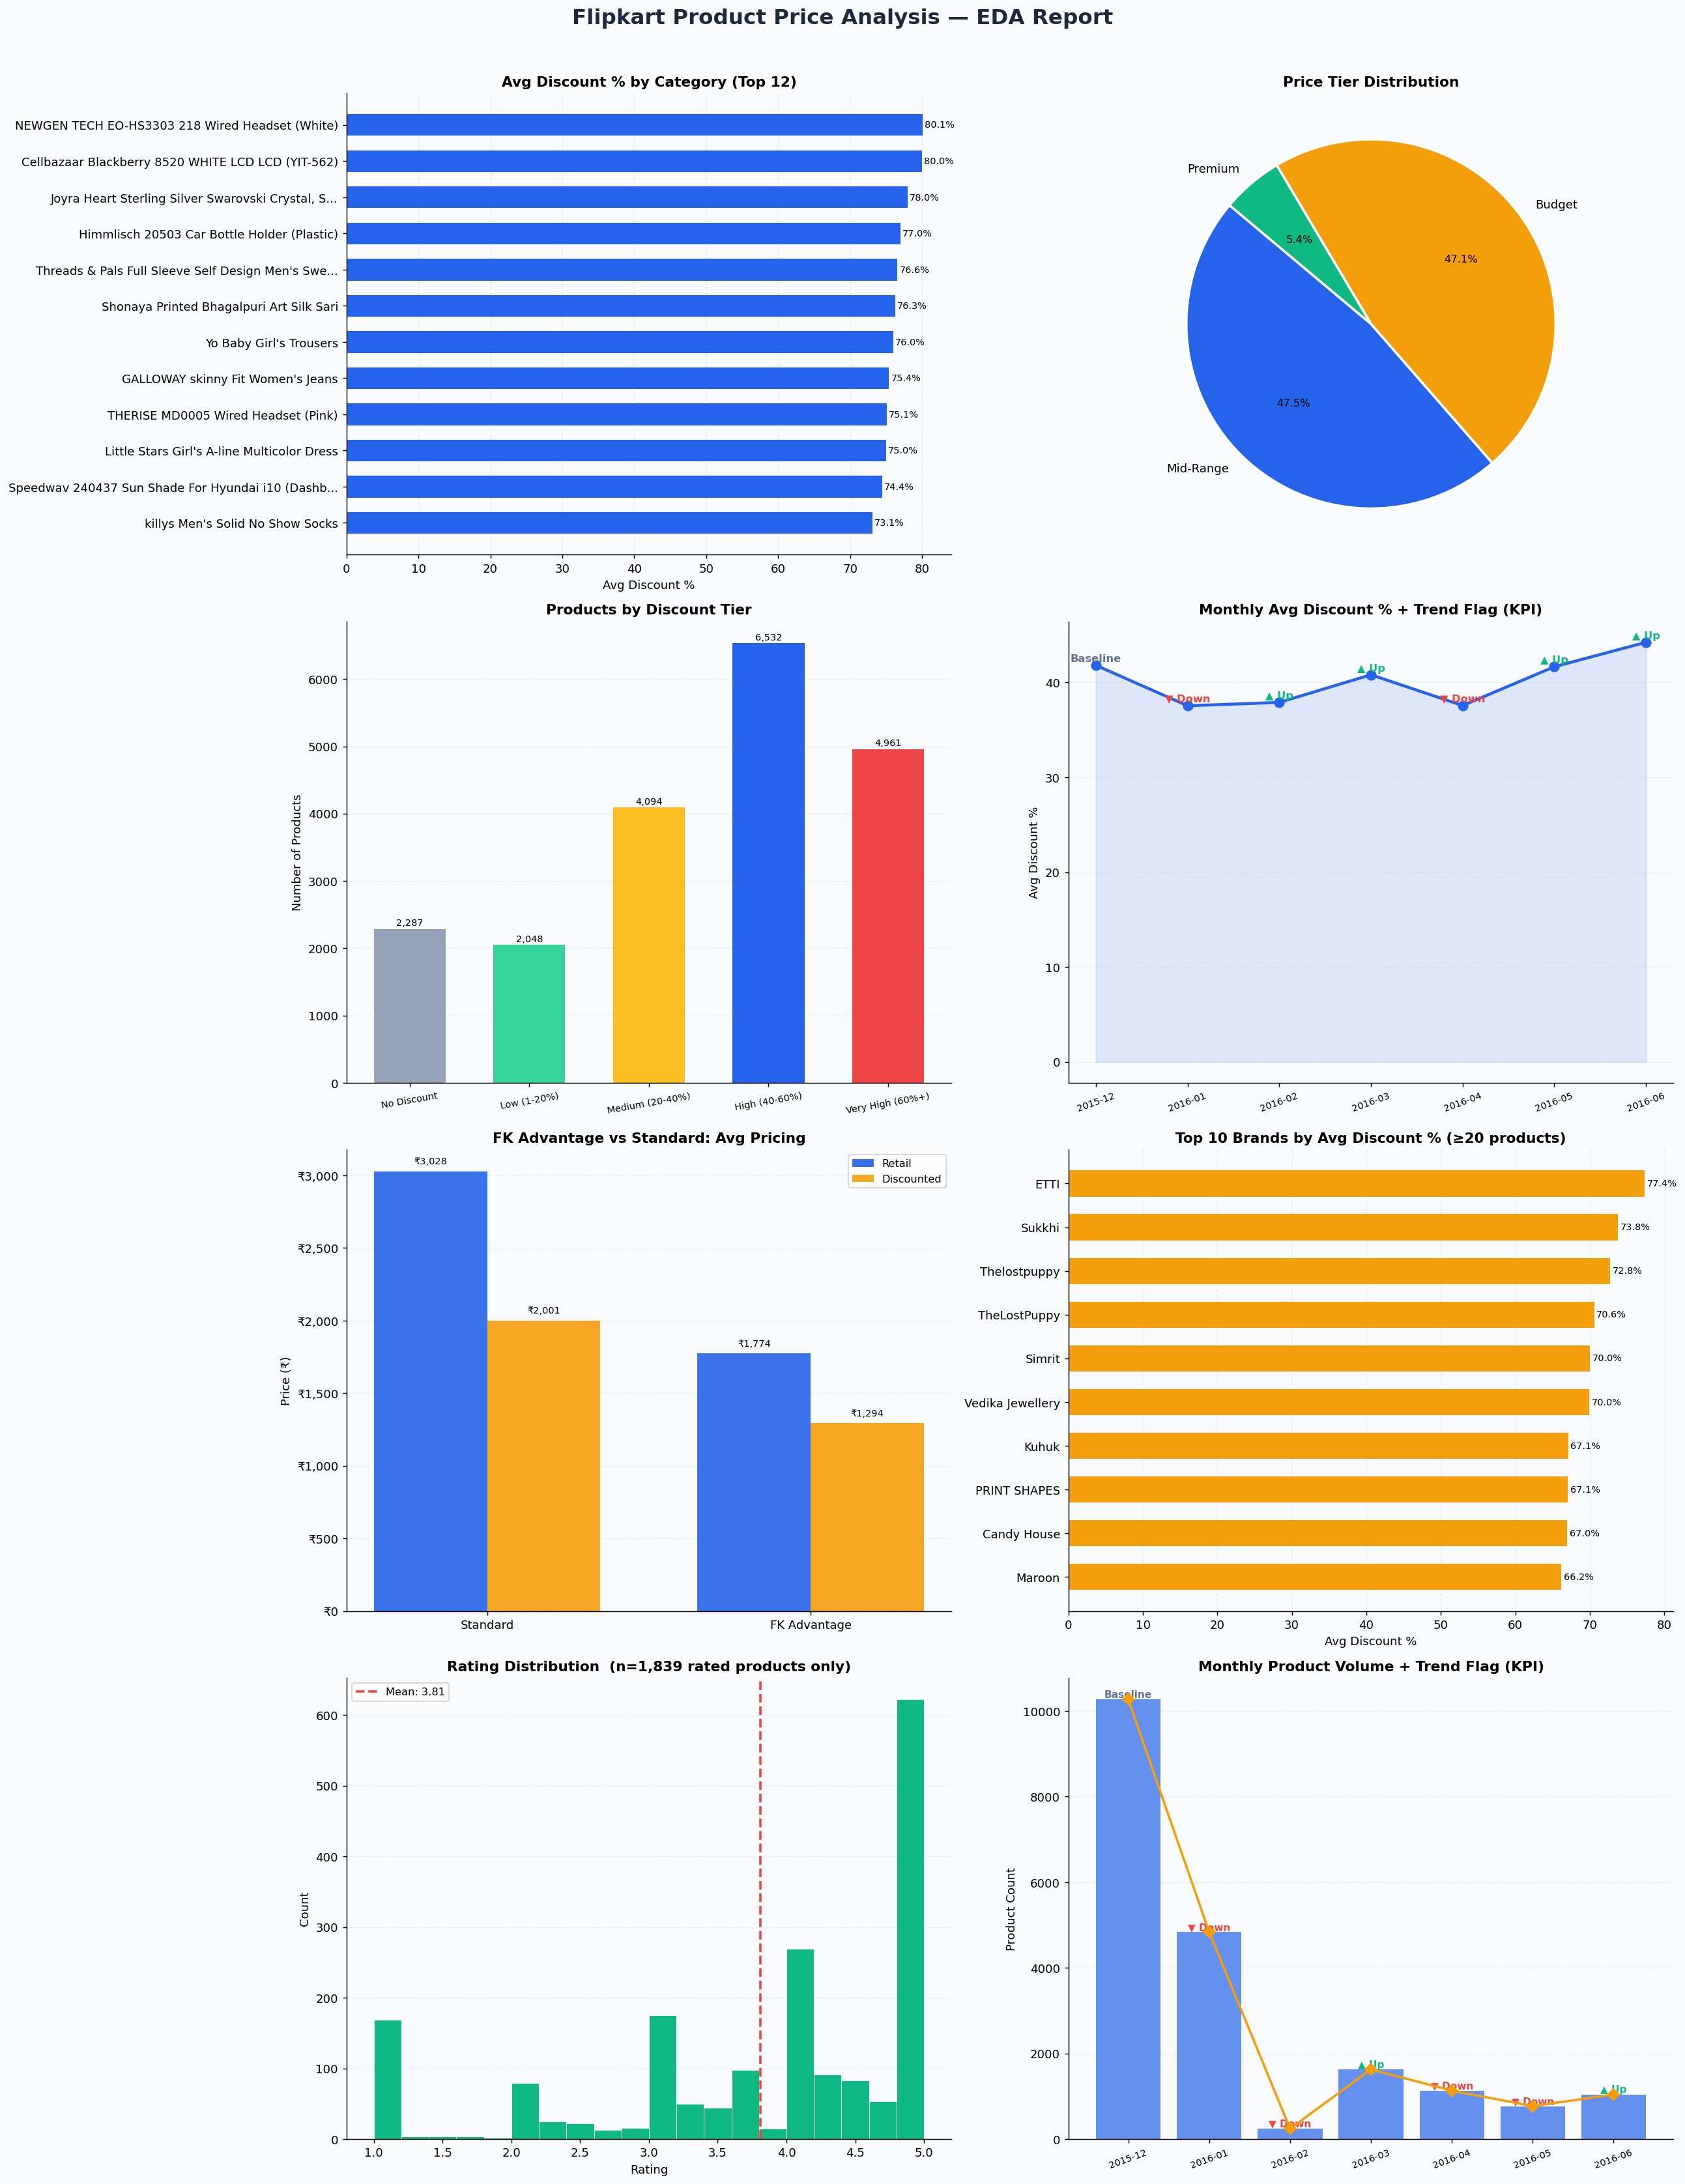

 EDA report saved as 'flipkart_eda_report.png'


In [14]:
BRAND_COLOR = '#2563EB'
ACCENT      = '#F59E0B'
BG          = '#F8FAFC'
GRID_C      = '#E2E8F0'
GREEN       = '#10B981'
RED         = '#EF4444'

plt.rcParams.update({
    'font.family' : 'DejaVu Sans',
    'figure.dpi'  : 130,
    'axes.spines.top'   : False,
    'axes.spines.right' : False
})

fig, axes = plt.subplots(4, 2, figsize=(20, 26), facecolor=BG)
fig.suptitle('Flipkart Product Price Analysis — EDA Report',
             fontsize=18, fontweight='bold', y=0.99, color='#1E293B')

ax = axes[0, 0]
cat_disc = df.groupby('L1_category')['discount_pct'].mean().sort_values(ascending=False).head(12)
bars = ax.barh(cat_disc.index[::-1], cat_disc.values[::-1], color=BRAND_COLOR, height=0.6)
for bar, val in zip(bars, cat_disc.values[::-1]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=8)
ax.set_title('Avg Discount % by Category (Top 12)', fontweight='bold')
ax.set_xlabel('Avg Discount %')
ax.set_facecolor(BG)
ax.xaxis.grid(True, color=GRID_C, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

ax = axes[0, 1]
tier_counts = df['price_tier'].value_counts()
wedges, texts, autotexts = ax.pie(
    tier_counts, labels=tier_counts.index, autopct='%1.1f%%',
    colors=[BRAND_COLOR, ACCENT, GREEN], startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts: at.set_fontsize(9)
ax.set_title('Price Tier Distribution', fontweight='bold')

ax = axes[1, 0]
dt_order  = ['No Discount','Low (1-20%)','Medium (20-40%)','High (40-60%)','Very High (60%+)']
dt_counts = df['discount_tier'].value_counts().reindex(dt_order)
colors_bar = ['#94A3B8','#34D399','#FBBF24', BRAND_COLOR, RED]
bars3 = ax.bar(dt_counts.index, dt_counts.values, color=colors_bar, edgecolor='none', width=0.6)
for bar, val in zip(bars3, dt_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', fontsize=8)
ax.set_title('Products by Discount Tier', fontweight='bold')
ax.set_ylabel('Number of Products')
ax.set_facecolor(BG)
ax.yaxis.grid(True, color=GRID_C, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
ax.tick_params(axis='x', labelsize=8, rotation=10)

ax = axes[1, 1]
months_list = monthly_kpi['crawl_month'].tolist()
disc_vals   = monthly_kpi['avg_discount_pct'].tolist()
ax.plot(months_list, disc_vals, color=BRAND_COLOR, marker='o', linewidth=2.5, markersize=8)
ax.fill_between(months_list, disc_vals, alpha=0.12, color=BRAND_COLOR)
for i, (m, v, flag) in enumerate(zip(months_list, disc_vals, monthly_kpi['discount_trend_flag'])):
    color = GREEN if '▲' in flag else RED if '▼' in flag else '#64748B'
    ax.text(i, v + 0.4, flag, ha='center', fontsize=9, color=color, fontweight='bold')
ax.set_title('Monthly Avg Discount % + Trend Flag (KPI)', fontweight='bold')
ax.set_ylabel('Avg Discount %')
ax.set_facecolor(BG)
ax.yaxis.grid(True, color=GRID_C, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
ax.tick_params(axis='x', labelsize=8, rotation=20)

ax = axes[2, 0]
fk_comp = df.groupby('is_fk_advantage')[['retail_price','discounted_price']].mean()
fk_comp.index = ['Standard', 'FK Advantage']
x = np.arange(len(fk_comp)); w = 0.35
b1 = ax.bar(x - w/2, fk_comp['retail_price'],     width=w, label='Retail',     color=BRAND_COLOR, alpha=0.9)
b2 = ax.bar(x + w/2, fk_comp['discounted_price'],  width=w, label='Discounted', color=ACCENT,      alpha=0.9)
for b in [*b1, *b2]:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 50,
            f'₹{b.get_height():,.0f}', ha='center', fontsize=8)
ax.set_title('FK Advantage vs Standard: Avg Pricing', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(fk_comp.index)
ax.set_ylabel('Price (₹)'); ax.legend(fontsize=9)
ax.set_facecolor(BG)
ax.yaxis.grid(True, color=GRID_C, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

ax = axes[2, 1]
brand_disc = (df[df['brand_clean'] != 'Unbranded']
              .groupby('brand_clean')
              .agg(avg_disc=('discount_pct','mean'), cnt=('product_name','count'))
              .query('cnt >= 20')
              .sort_values('avg_disc', ascending=False)
              .head(10))
bars6 = ax.barh(brand_disc.index[::-1], brand_disc['avg_disc'][::-1], color=ACCENT, height=0.6)
for bar, val in zip(bars6, brand_disc['avg_disc'][::-1]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=8)
ax.set_title('Top 10 Brands by Avg Discount % (≥20 products)', fontweight='bold')
ax.set_xlabel('Avg Discount %')
ax.set_facecolor(BG)
ax.xaxis.grid(True, color=GRID_C, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

ax = axes[3, 0]
rated = df[df['is_rated'] == 1]['rating_clean'].dropna()
ax.hist(rated, bins=20, color=GREEN, edgecolor='white', linewidth=0.5)
ax.axvline(rated.mean(), color=RED, linestyle='--', linewidth=2,
           label=f'Mean: {rated.mean():.2f}')
ax.set_title(f'Rating Distribution  (n={len(rated):,} rated products only)', fontweight='bold')
ax.set_xlabel('Rating'); ax.set_ylabel('Count')
ax.legend(fontsize=9)
ax.set_facecolor(BG)
ax.yaxis.grid(True, color=GRID_C, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

ax = axes[3, 1]
ax.bar(months_list, monthly_kpi['product_count'], color=BRAND_COLOR, alpha=0.7, edgecolor='none')
ax.plot(months_list, monthly_kpi['product_count'],
        color=ACCENT, marker='D', linewidth=2, markersize=7, zorder=5)
ax.set_title('Monthly Product Volume + Trend Flag (KPI)', fontweight='bold')
ax.set_ylabel('Product Count')
ax.set_facecolor(BG)
ax.yaxis.grid(True, color=GRID_C, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
ax.tick_params(axis='x', labelsize=8, rotation=20)
for i, (_, row) in enumerate(monthly_kpi.iterrows()):
    flag  = row['volume_trend_flag']
    color = GREEN if '▲' in flag else RED if '▼' in flag else '#64748B'
    ax.text(i, row['product_count'] + 50, flag, ha='center', fontsize=8.5, color=color, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('flipkart_eda_report.png', bbox_inches='tight', facecolor=BG, dpi=150)
plt.show()
print(" EDA report saved as 'flipkart_eda_report.png'")

## 13. Cleaned Dataset Summary

In [15]:
print("=" * 55)
print("       FLIPKART CLEANED DATASET — SUMMARY")
print("=" * 55)
print(f"  Total Products       : {len(df):,}")
print(f"  Columns              : {df.shape[1]}")
print(f"  L1 Categories        : {df['L1_category'].nunique()}")
print(f"  Unique Brands        : {df['brand_clean'].nunique():,}")
print(f"  Avg Retail Price     : ₹{df['retail_price'].mean():,.0f}")
print(f"  Avg Discounted Price : ₹{df['discounted_price'].mean():,.0f}")
print(f"  Avg Discount %       : {df['discount_pct'].mean():.1f}%")
print(f"  Max Discount %       : {df['discount_pct'].max():.1f}%")
print(f"  Total Savings (all)  : ₹{df['savings_amount'].sum():,.0f}")
print(f"  FK Advantage Prods   : {df['is_fk_advantage'].sum():,}")
print(f"  Rated Products       : {df['is_rated'].sum():,} ({df['is_rated'].mean()*100:.1f}%)")
print(f"  Avg Rating (rated)   : {df[df['is_rated']==1]['rating_clean'].mean():.2f}")
print(f"  Price Outliers (>p99): {df['is_price_outlier'].sum():,}")
print("=" * 55)
print()
print("Null check in final dataset:")
null_check = df.isnull().sum()
null_check = null_check[null_check > 0]
if len(null_check) == 0:
    print("  No unexpected nulls (rating NaN is intentional)")
else:
    print(null_check.to_string())

       FLIPKART CLEANED DATASET — SUMMARY
  Total Products       : 19,922
  Columns              : 25
  L1 Categories        : 262
  Unique Brands        : 3,466
  Avg Retail Price     : ₹2,979
  Avg Discounted Price : ₹1,973
  Avg Discount %       : 40.5%
  Max Discount %       : 96.5%
  Total Savings (all)  : ₹20,037,634
  FK Advantage Prods   : 768
  Rated Products       : 1,839 (9.2%)
  Avg Rating (rated)   : 3.81
  Price Outliers (>p99): 200

Null check in final dataset:
rating_clean    18083


## 14. Save Cleaned CSV &  Connecting  Dataset  to PostgreSQL for further analysis

In [16]:
output_path = 'flipkart_cleaned.csv'
df.to_csv(output_path, index=False)

import os
from sqlalchemy import create_engine

username = os.environ.get('PG_USER', 'postgres')
password = os.environ.get('PG_PASSWORD', '')
host = os.environ.get('PG_HOST', 'localhost')
port = os.environ.get('PG_PORT', '5432')
database = os.environ.get('PG_DB', 'flipkart_price_db')

engine = create_engine(f'postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}')

df.to_sql('flipkart_products', engine, if_exists='replace', index=False)
print(f'Data loaded into PostgreSQL table: flipkart_products')

Data loaded into PostgreSQL table: flipkart_products
